# Q2 - Unsupervised Learning: Customer Segmentation 
Group customers into meaningful segments using K-Means Clustering, then visualise the results using PCA

# Task 1 - Data Preparation

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import  seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans #the clustering algorithm
from sklearn.decomposition import PCA #dimensionality reduction tool

df = pd.read_csv('q2_customers.csv')

print(f"Dataset Shape: {df.shape[0]} rows * {df.shape[1]} columns")

print(f"\nData Types:")
print(df.dtypes) # data types of each column

print(f"\nMissing values per column:")
print(df.isnull().sum())

print(f"\nBasic Statistics:")
df.describe().round(2)

Dataset Shape: 500 rows * 6 columns

Data Types:
age                         int64
annual_spend                int64
visits_per_month            int64
basket_size                 int64
days_since_last_visit       int64
num_categories_purchased    int64
dtype: object

Missing values per column:
age                         0
annual_spend                0
visits_per_month            0
basket_size                 0
days_since_last_visit       0
num_categories_purchased    0
dtype: int64

Basic Statistics:


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
count,500.00,500.00,500.00,500.00,500.00,500.00
mean,40.45,48856.95,8.41,2682.29,49.47,4.66
std,14.43,32856.80,5.32,2274.96,49.70,2.44
min,18.00,5038.00,1.00,212.00,0.00,1.00
25%,28.00,19213.25,4.00,727.75,12.00,3.00
50%,41.00,44257.00,8.00,2051.50,33.00,4.00
75%,50.00,75373.00,12.00,4223.75,61.25,6.00
max,69.00,119757.00,19.00,7981.00,179.00,9.00


In [31]:
# Scaling

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df) #scale entire dataset as there is no train/test split

X_scaled_df = pd.DataFrame(X_scaled, columns=df.columns) #convert back into dataframe to verify it worked

print(f"Scaled Data - first 5 rows:")
print(X_scaled_df.head().round(3).to_string())

print(f"\nMean after scaling (should be = 0):")
print(X_scaled_df.mean().round(4).to_string())

print(f"\nStd after scaling (should be = 1):")
print(X_scaled_df.std().round(4).to_string())


Scaled Data - first 5 rows:
     age  annual_spend  visits_per_month  basket_size  days_since_last_visit  num_categories_purchased
0 -0.725        -0.176             0.110       -0.265                 -0.090                     0.551
1 -1.488        -1.047             0.486       -0.980                 -0.835                    -0.681
2  0.177         0.267            -0.454       -0.237                 -0.674                    -0.270
3 -0.725        -1.012             0.298       -0.828                 -0.996                    -1.091
4 -1.488        -1.034             1.426       -1.006                 -0.654                    -1.502

Mean after scaling (should be = 0):
age                         0.0
annual_spend                0.0
visits_per_month            0.0
basket_size                -0.0
days_since_last_visit      -0.0
num_categories_purchased   -0.0

Std after scaling (should be = 1):
age                         1.001
annual_spend                1.001
visits_per_month     

# Why is Scaling essential before K-Means?

K-Means groups data based on distance, but if features are on very different scales, larger values (like annual spend) dominate the calculation. This makes the model ignore smaller-scale features like age or visits.

Scaling fixes this by bringing all features to the same level, so each one contributes equally—resulting in more balanced and meaningful clusters.

# Task 2 - Choosing K - Elbow Method

Finding the optimal K (hw many customer group)

In [32]:
# Compute WCSS for K = 1 to 10

wcss = []

for k in range(1, 11): #loop from k=1 to k=10
    km = KMeans(n_clusters=k, random_state=42, n_init=10) #run K-Means 10 times with different starting points and pick the best
    km.fit(X_scaled) #train the model
    wcss.append(km.inertia_) #value of wcss after training
    print(f"K ={k:2d} - WCSS: {km.inertia_:.2f}")


K = 1 - WCSS: 3000.00
K = 2 - WCSS: 968.99
K = 3 - WCSS: 561.25
K = 4 - WCSS: 444.93
K = 5 - WCSS: 402.37
K = 6 - WCSS: 370.39
K = 7 - WCSS: 346.95
K = 8 - WCSS: 319.90
K = 9 - WCSS: 303.28
K =10 - WCSS: 289.11


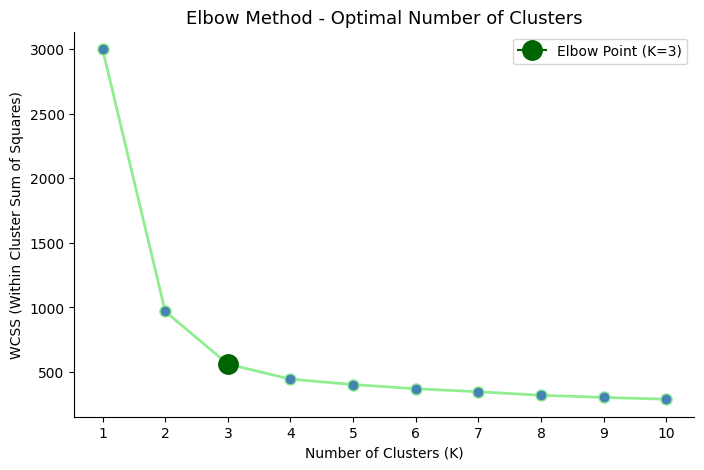

In [33]:
# Plot the Elbow Curve
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(range(1, 11), wcss, marker='o', color='lightgreen', 
        linewidth=2, markersize=8, markerfacecolor='steelblue')

ax.plot(3, wcss[2], marker='o', markersize=14, color='darkgreen',
        label='Elbow Point (K=3)', zorder=5)

ax.set_title('Elbow Method - Optimal Number of Clusters', fontsize=13)
ax.set_xlabel('Number of Clusters (K)')
ax.set_ylabel('WCSS (Within Cluster Sum of Squares)')
ax.set_xticks(range(1, 11))
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout
plt.show()


# Optimal K Selection 

Optimal K = 3 - (561.25)

The curve drops steeply from k=1 (3000) to k=3 (561.25), then flattens significantly after k=3. The most noticeable bond - the elbow - occurs at K=3. Adding a 4th cluster (444.93) only reduces WCSS by 116 points compared to 407 points gained from K=2 to K=3. Beyond K=3 the improvement is minimal and not worth the added complexity. K=3 gives us 3 clean, interpretable customer segments

# Task 3 - K - Means Clustering

Fit K-Means with K=3 and analyse the resulting customer segments

In [34]:
km = KMeans(n_clusters=3, random_state=42, n_init=10)
km.fit(X_scaled)

df['cluster'] = km.labels_

print(f"Cluster Assignment Complete.")
print(f"\nCluster Sizes:")
print(df['cluster'].value_counts().sort_index()) #counts how many customers are in each cluster

print(f"\nCluster sizes as Percentage:")
sizes = df['cluster'].value_counts(normalize=True).sort_index() * 100
for cluster, pct in sizes.items():
    print(f" Cluster {cluster}: {pct:.1f}%")



Cluster Assignment Complete.

Cluster Sizes:
cluster
0    170
1    165
2    165
Name: count, dtype: int64

Cluster sizes as Percentage:
 Cluster 0: 34.0%
 Cluster 1: 33.0%
 Cluster 2: 33.0%


In [35]:
centroids = pd.DataFrame(
    scaler.inverse_transform(km.cluster_centers_), #converts them back to original scale so we can read them meaningfully
    columns=df.columns[:-1] #all column names except the last one
)
centroids.index.name = 'Cluster'

print(f"Cluster Centroids (in original scale):")
print(centroids.round(1).to_string())

Cluster Centroids (in original scale):
          age  annual_spend  visits_per_month  basket_size  days_since_last_visit  num_categories_purchased
Cluster                                                                                                    
0        24.7       14847.4              14.3        559.0                    9.1                       2.1
1        56.8       89413.3               2.5       5530.5                  105.4                       7.5
2        40.4       43340.7               8.2       2021.7                   35.2                       4.4


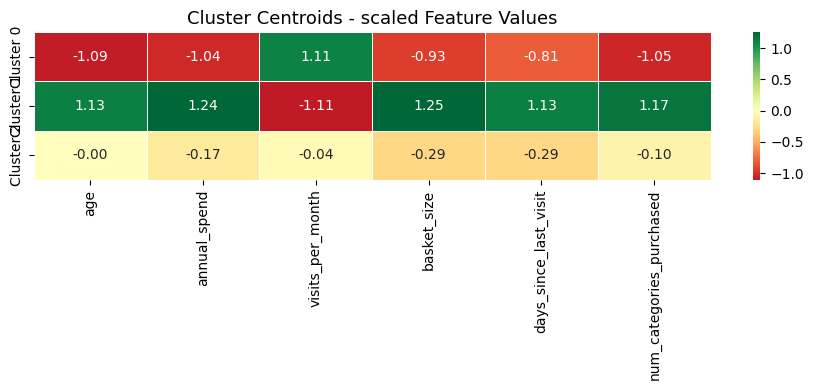

In [36]:
fig, ax = plt.subplots(figsize=(9, 4)) #visualise cluster profiles with a heatmap

centroid_scaled = pd.DataFrame(km.cluster_centers_,
                               columns=df.columns[:-1])
centroid_scaled.index = [f'Cluster {i}' for i in range(3)] #creates labels

sns.heatmap(centroid_scaled, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, ax=ax)
ax.set_title('Cluster Centroids - scaled Feature Values', fontsize=13)
plt.tight_layout()
plt.show()

# Business Interpretation of Clusters

Cluster 0 — Young Frequent Low-Spenders (34%)
Young, frequent visitors with low spend. Budget-conscious shoppers.
We should focus on Upsell & cross-sell

Cluster 1 — Older Wealthy Infrequent Shoppers (33%)
High spend but rare visits and long inactivity. High value but churn risk.
We should focus on Re-engagement campaigns

Cluster 2 — Middle-Aged Moderate Shoppers (33%)
Balanced spend, visits, and recent activity. Loyal and stable segment.
We should focus on Loyalty & retention programs

# Task 4 - Dimensionality Reduction with PCA

Principal component Analysis reduces 6 features down to 2 while keeping as much information as possible

In [37]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled) #learns the best direction AND transforms the data 

print(f"Original Shape: {X_scaled.shape} - {X_scaled.shape[1]} features")
print(f"PCA Shape: {X_pca.shape} - {X_pca.shape[1]} components")

print(f"\nExplained Variance Ratio:")
for i, var in enumerate(pca.explained_variance_ratio_): #how much of the total info each component captures
    print(f" PC{i+1}: {var:.4f} ({var*100:.2f}% of variance)")

print(f"\nTotal Variance Explained: {pca.explained_variance_ratio_.sum()*100:.2f}%") #how much of all information we kept nearly in just 2 dimensions

Original Shape: (500, 6) - 6 features
PCA Shape: (500, 2) - 2 components

Explained Variance Ratio:
 PC1: 0.8356 (83.56% of variance)
 PC2: 0.0557 (5.57% of variance)

Total Variance Explained: 89.13%


Feature Loadings:
       age  annual_spend  visits_per_month  basket_size  days_since_last_visit  num_categories_purchased
PC1  0.412         0.422            -0.410        0.412                  0.379                     0.414
PC2 -0.259        -0.033             0.208       -0.195                  0.911                    -0.140


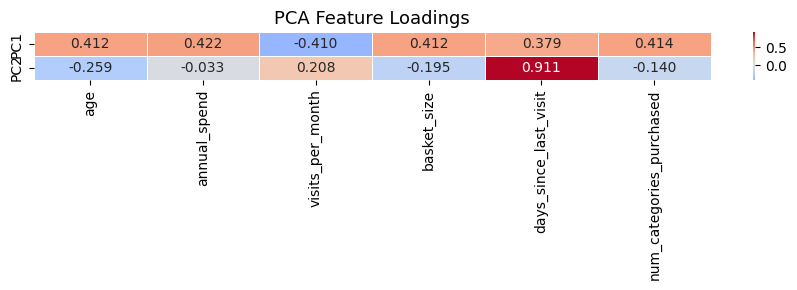

In [38]:
#Feature Loadings

loadings = pd.DataFrame(
    pca.components_, #shows how much each original feature contributes to each PC
    columns=df.columns[:-1],
    index = ['PC1', 'PC2']
)

print(f"Feature Loadings:")
print(loadings.round(3).to_string())

fig, ax = plt.subplots(figsize=(9, 3))
sns.heatmap(loadings, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax)
ax.set_title('PCA Feature Loadings', fontsize=13)
plt.tight_layout()
plt.show()


# Interpretation of PC1 and PC2

Explained Variance:
PC1 = 83.56%, PC2 = 5.57% → ~89% total (most information captured in 2 components)

PC1 — Customer Value Axis
Separates customers by overall value:

    High - older, high spend, large basket, fewer visits
    Low - younger, low spend, frequent visits
        It ranks customers from From frequent low spenders → infrequent high spenders

PC2 — Recency Axis
Driven by last visit timing:

    High → not visited recently (at risk)
    Low → recent/active customers

# Task 5 - Cluster Visualisation

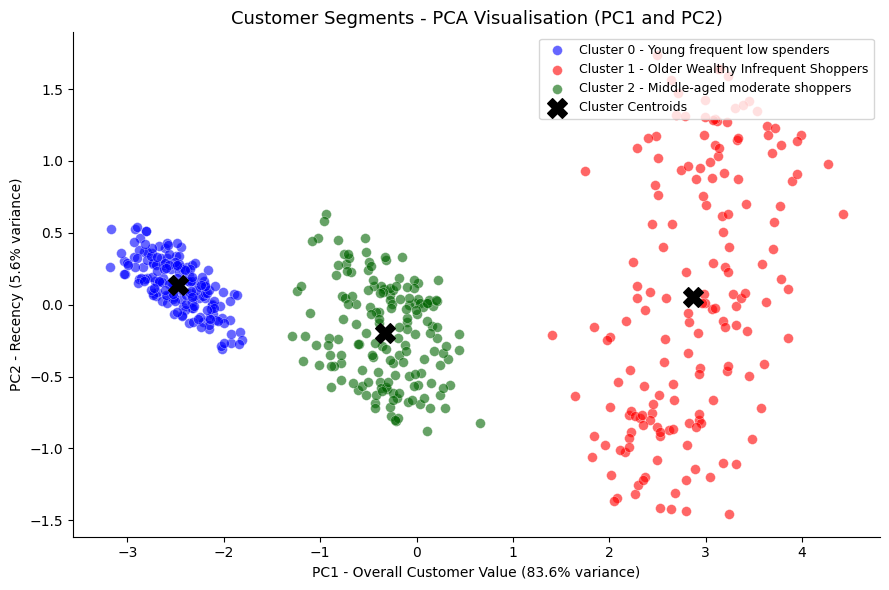

In [39]:
colors = ['blue', 'red', 'darkgreen']
labels = ['Cluster 0 - Young frequent low spenders',
          'Cluster 1 - Older Wealthy Infrequent Shoppers',
          'Cluster 2 - Middle-aged moderate shoppers']

fig , ax = plt.subplots(figsize=(9, 6))

for cluster_id, (color, label) in enumerate(zip(colors, labels)): #gives counter+color+label
    mask = df['cluster'] == cluster_id # created True/False filter -------- True for customers in this clusters
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], # PC1 and PC2 values for only this cluster's customers ----- plotting each clusters seperately
               color=color, label=label, alpha=0.6, s=50, edgecolors='white', linewidths=0.3)
    

centroids_pca = pca.transform(km.cluster_centers_)
ax.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
           color='black', marker='X', s=200, zorder=5, label='Cluster Centroids')


ax.set_title('Customer Segments - PCA Visualisation (PC1 and PC2)', fontsize=13)
ax.set_xlabel(f'PC1 - Overall Customer Value ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 - Recency ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.legend(loc='upper right', fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

# Scatter Plot Interpretation

The plot shows 3 clearly separated customer groups:

1) Cluster 0 (Blue) — 

Left side - low PC1 - frequent, low spenders

2) Cluster 1 (Red) — 

Right side - high PC1 - high spenders, some inactive (higher PC2)

3) Cluster 2 (Green) — 

Middle - moderate behaviour

 Black X marks indicate cluster centroids.
 
 Clear separation confirms K=3 is a good fit with distinct, non-overlapping groups.